# Drone Video → 3D Building Model (COLMAP)

Pipeline: **video → frames → feature extraction → matching → sparse 3D reconstruction (SfM) → mesh → export**.

Uses [COLMAP](https://colmap.github.io/) — the standard free/open-source Structure-from-Motion + Multi-View Stereo tool (same category of thing as RealityCapture/Metashape, but free and scriptable).

**Important for Mac users:** COLMAP's dense reconstruction stage (`patch_match_stereo`) requires an NVIDIA GPU + CUDA, which Apple Silicon / Intel Macs don't have. This notebook detects that and automatically falls back to building the mesh directly from the sparse point cloud (`delaunay_mesher --input_type sparse`), which is CPU-only. You'll get a lower-fidelity mesh than a full dense reconstruction, but it works entirely locally. If you later have access to a CUDA machine (e.g. a cloud GPU box), you can rerun the dense cells there for a much higher-quality result.

## 0. System dependencies

COLMAP and ffmpeg are not Python packages — install them once via Homebrew:

```
brew install colmap ffmpeg
```

COLMAP has a prebuilt macOS bottle so this shouldn't require compiling, but it does pull ~20 dependencies (Ceres, CGAL, Qt, etc.) so it'll take a few minutes.

Run the cell below to check whether they're already on PATH.

In [1]:
import shutil, subprocess

def check_tool(name, args=("-h",)):
    path = shutil.which(name)
    if path is None:
        print(f"✗ {name} not found on PATH")
        return False
    print(f"✓ {name} → {path}")
    return True

have_colmap = check_tool("colmap")
have_ffmpeg = check_tool("ffmpeg", ("-version",))

if not (have_colmap and have_ffmpeg):
    print("\nMissing dependencies — install with:\n\n    brew install colmap ffmpeg\n\nthen re-run this cell.")

✓ colmap → /opt/homebrew/bin/colmap
✓ ffmpeg → /opt/homebrew/bin/ffmpeg


In [ ]:
!pip install -q pycolmap trimesh opencv-python-headless numpy matplotlib tqdm

## 1. Config

In [ ]:
from pathlib import Path

# ── INPUT ──────────────────────────────────────────────────────────────
VIDEO_PATH = Path("media/short.mp4")   # ← change this

# ── WORKSPACE ────────────────────────────────────────────────────────
WORKSPACE  = Path("colmap_ws")
IMAGES_DIR = WORKSPACE / "images"
SPARSE_DIR = WORKSPACE / "sparse"
DENSE_DIR  = WORKSPACE / "dense"
DATABASE   = WORKSPACE / "database.db"

for d in (IMAGES_DIR, SPARSE_DIR, DENSE_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ── FRAME EXTRACTION ────────────────────────────────────────────────
EXTRACT_FPS      = 6      # frames/sec pulled from the video — raise this (e.g. 4-6) to get MORE frames / denser overlap
                          # 6 is tuned for a short handheld pan around a static object (like the panel); for a long
                          # drone orbit of a whole building, 2 is usually enough and keeps runtime down.
BLUR_THRESHOLD   = 100.0  # drop frames blurrier than this (variance of Laplacian); set to None to disable
CLEAR_OLD_FRAMES = True   # True  = wipe frames + database + reconstruction before this run (fresh/different video)
                          # False = keep existing frames and append new ones (combine multiple videos of the same building)

# ── COLMAP ─────────────────────────────────────────────────────────────────
CAMERA_MODEL = "OPENCV"  # single-lens distortion model; try SIMPLE_RADIAL if calibration looks off
LOOP_CLOSURE = True       # only kicks in if VOCAB_TREE_PATH below is set — big help if the drone orbits back near its start
VOCAB_TREE_PATH = None    # download e.g. vocab_tree_flickr100K_words32K.bin from https://demuc.de/colmap/#download

# Extra flags passed straight to `colmap mapper` — empty list restores COLMAP defaults.
# Tested on this panel's data: a purely lateral pan gives bundle adjustment too little angular
# diversity to separate true depth from lens distortion, so it "explains" the flat surface with a
# slight dome/bowl curve ("doming" — a known photogrammetry artifact). Freezing focal length +
# distortion refinement measurably reduced it here (depth-std/width-std ratio: 46% → 38%, plus
# more points survived filtering). Remove either flag to A/B test its individual contribution, or
# clear the whole list to compare against COLMAP's untouched defaults.
MAPPER_EXTRA_ARGS = ["--Mapper.ba_refine_focal_length", "0", "--Mapper.ba_refine_extra_params", "0"]
# Other flags worth trying:
#   ["--Mapper.init_min_tri_angle", "4"]   lowers the minimum triangulation angle (default 16°)
#                                          required to bootstrap reconstruction — helpful if frames
#                                          fail to register on a narrow-baseline capture.

# ── POINT CLOUD FILTERING ───────────────────────────────────────────────────
# Raw COLMAP points always include noisy outliers — points seen in very few images, or triangulated
# with high reprojection error. These are what make a flat surface look like scattered "geometric
# shapes" instead of a clean plane. Tune these to trade off density vs cleanliness:
MIN_TRACK_LENGTH = 3     # keep only points triangulated from at least this many images — raise to 4-5 for a cleaner/sparser cloud
MAX_REPROJ_ERROR = 2.0   # keep only points with reprojection error under this many pixels — lower = stricter/cleaner

print(f"Video: {VIDEO_PATH}  (exists: {VIDEO_PATH.exists()})")
print(f"Workspace: {WORKSPACE.resolve()}")

In [22]:
!pip install yt-dlp
!yt-dlp -f "bestvideo[height<=1080]" "https://www.youtube.com/watch?v=V9VkKo4nAGc" -o footage.mp4

[youtube] Extracting URL: https://www.youtube.com/watch?v=V9VkKo4nAGc
[youtube] V9VkKo4nAGc: Downloading webpage
[youtube] V9VkKo4nAGc: Downloading android vr player API JSON
[info] V9VkKo4nAGc: Downloading 1 format(s): 248
[download] Destination: footage.mp4
[download] 100% of   12.61MiB in 00:00:01 at 11.69MiB/s;33m00:000m


## 2. Extract frames from video (ffmpeg)

For good SfM results you want **70–90% overlap** between consecutive frames and minimal motion blur. `EXTRACT_FPS` controls overlap (higher fps = more overlap = more robust matching, but slower reconstruction).

If your reconstruction splits into multiple disconnected pieces (see the warning after the mapper step below), that means there wasn't enough overlap — raise `EXTRACT_FPS` and re-run from here with `CLEAR_OLD_FRAMES = True` (set in the config cell above) so the old frames/database/reconstruction are wiped before the new extraction.

In [3]:
def next_frame_index(out_dir):
    existing = sorted(out_dir.glob("frame_*.jpg"))
    if not existing:
        return 0
    return int(existing[-1].stem.split("_")[1]) + 1

def extract_frames_ffmpeg(video_path, out_dir, fps=2, clear_existing=True):
    if clear_existing:
        for f in out_dir.glob("frame_*.jpg"):
            f.unlink()
        if DATABASE.exists():
            DATABASE.unlink()
        shutil.rmtree(SPARSE_DIR, ignore_errors=True)
        shutil.rmtree(DENSE_DIR, ignore_errors=True)
        for d in (SPARSE_DIR, DENSE_DIR):
            d.mkdir(parents=True, exist_ok=True)
        print("Cleared previous frames + database + reconstruction.")
        start = 0
    else:
        start = next_frame_index(out_dir)
        print(f"Keeping existing frames — appending new ones starting at index {start}.")

    pattern = str(out_dir / "frame_%05d.jpg")
    cmd = ["ffmpeg", "-y", "-i", str(video_path), "-vf", f"fps={fps}",
           "-qscale:v", "2", "-start_number", str(start), pattern]
    print("Running:", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stderr[-2000:])
        raise RuntimeError("ffmpeg failed — see stderr above")
    frames = sorted(out_dir.glob("frame_*.jpg"))
    print(f"Extracted → {out_dir} (total frames now: {len(frames)})")
    return frames

frame_paths = extract_frames_ffmpeg(VIDEO_PATH, IMAGES_DIR, EXTRACT_FPS, clear_existing=CLEAR_OLD_FRAMES)

Cleared previous frames + database + reconstruction.
Running: ffmpeg -y -i media/short.mp4 -vf fps=6 -qscale:v 2 -start_number 0 colmap_ws/images/frame_%05d.jpg
Extracted → colmap_ws/images (total frames now: 66)


## 3. Drop blurry frames (optional)

Fast drone motion causes motion blur, which hurts feature matching. This scores each frame by the variance of its Laplacian (a sharpness proxy) and drops the blurriest ones.

In [4]:
import cv2
import numpy as np

def blur_score(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    return cv2.Laplacian(img, cv2.CV_64F).var()

if BLUR_THRESHOLD is not None:
    kept, dropped = [], []
    for p in frame_paths:
        (kept if blur_score(p) >= BLUR_THRESHOLD else dropped).append(p)
    for p in dropped:
        p.unlink()
    print(f"Dropped {len(dropped)} blurry frames, kept {len(kept)}")
    frame_paths = kept
else:
    print("Blur filtering disabled")

Dropped 0 blurry frames, kept 66


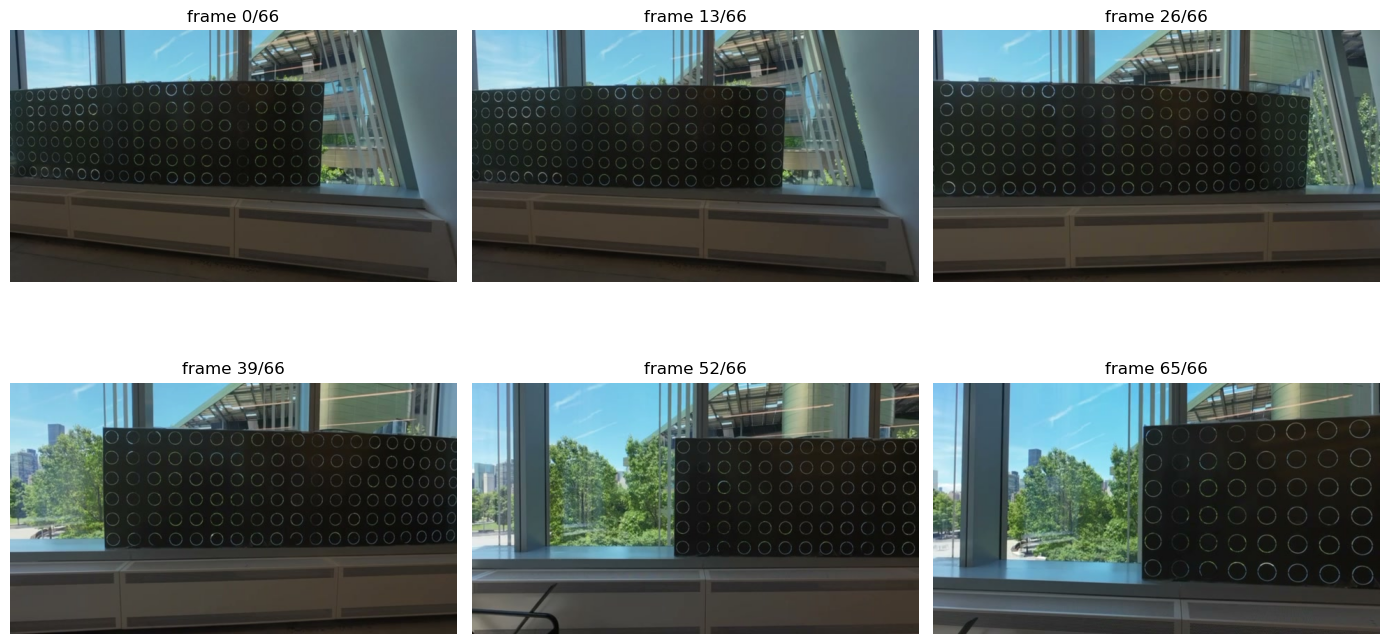

In [5]:
import matplotlib.pyplot as plt

sample_idx = np.linspace(0, len(frame_paths) - 1, 6).astype(int)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, i in zip(axes.flat, sample_idx):
    img = cv2.cvtColor(cv2.imread(str(frame_paths[i])), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"frame {i}/{len(frame_paths)}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Feature extraction + matching

Frames from a video are temporally ordered, so `sequential_matcher` (only compares nearby frames in time) is far faster than exhaustive matching. Loop closure detection helps a lot if the drone orbits all the way around the building and comes back near where it started — but it needs a downloaded vocabulary tree file (see `VOCAB_TREE_PATH` above).

In [6]:
def run(cmd):
    cmd = [str(c) for c in cmd]
    print("$", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stdout[-3000:])
        print(result.stderr[-3000:])
        raise RuntimeError(f"Command failed: {cmd[:2]}")
    return result

run([
    "colmap", "feature_extractor",
    "--database_path", DATABASE,
    "--image_path", IMAGES_DIR,
    "--ImageReader.single_camera", "1",
    "--ImageReader.camera_model", CAMERA_MODEL,
    # no GPU flag — COLMAP will auto-detect and fall back to CPU
])
print("Feature extraction done.")

$ colmap feature_extractor --database_path colmap_ws/database.db --image_path colmap_ws/images --ImageReader.single_camera 1 --ImageReader.camera_model OPENCV
Feature extraction done.


In [7]:
# Small frame counts (a slow pan around a static object, not a long drone orbit) benefit from
# exhaustive matching — every pair is checked, not just temporal neighbors. This matters a lot
# when the subject has repetitive texture (e.g. a grid of identical circles), which can fool
# sequential matching into missing valid matches that aren't adjacent in time.
EXHAUSTIVE_THRESHOLD = 150  # frame count below which we switch from sequential to exhaustive matching

if len(frame_paths) <= EXHAUSTIVE_THRESHOLD:
    matcher_cmd = ["colmap", "exhaustive_matcher", "--database_path", DATABASE]
    print(f"{len(frame_paths)} frames — using exhaustive_matcher.")
else:
    matcher_cmd = [
        "colmap", "sequential_matcher",
        "--database_path", DATABASE,
        "--SequentialMatching.overlap", "10",
    ]
    if LOOP_CLOSURE and VOCAB_TREE_PATH and Path(VOCAB_TREE_PATH).exists():
        matcher_cmd += [
            "--SequentialMatching.loop_detection", "1",
            "--SequentialMatching.vocab_tree_path", str(VOCAB_TREE_PATH),
        ]
    elif LOOP_CLOSURE:
        print("LOOP_CLOSURE requested but no vocab tree found — skipping loop detection.")
    print(f"{len(frame_paths)} frames — using sequential_matcher.")

run(matcher_cmd)
print("Matching done.")

66 frames — using exhaustive_matcher.
$ colmap exhaustive_matcher --database_path colmap_ws/database.db
Matching done.


## 5. Sparse reconstruction (Structure-from-Motion)

This is the core step: it jointly solves for every camera's 3D pose and a sparse 3D point cloud of the building. Pure CPU, works the same on every platform.

In [ ]:
run([
    "colmap", "mapper",
    "--database_path", DATABASE,
    "--image_path", IMAGES_DIR,
    "--output_path", SPARSE_DIR,
] + MAPPER_EXTRA_ARGS)

import pycolmap

models = sorted(p for p in SPARSE_DIR.iterdir() if p.is_dir())
print(f"Reconstructed {len(models)} model(s): {[m.name for m in models]}")
if not models:
    raise RuntimeError("No model reconstructed — see troubleshooting section at the bottom.")

# `models` are numbered in the order COLMAP happened to grow them, NOT by size — picking
# models[0] blindly can grab a tiny disconnected fragment (e.g. 2 registered images) instead
# of the real reconstruction. Pick the one with the most registered images instead.
model_sizes = {m: pycolmap.Reconstruction(str(m)).num_reg_images() for m in models}
print("Registered images per model:", {m.name: n for m, n in model_sizes.items()})
SPARSE_MODEL = max(model_sizes, key=model_sizes.get)
print(f"Using {SPARSE_MODEL.name} ({model_sizes[SPARSE_MODEL]} registered images)")

if len(models) > 1:
    print(f"WARNING: reconstruction split into {len(models)} disconnected pieces — usually means "
          f"not enough frame overlap. Raise EXTRACT_FPS (cell 1) and re-run from cell 2 onward "
          f"with CLEAR_OLD_FRAMES = True, or enable LOOP_CLOSURE with a vocab tree.")

Reconstruction:
	num_rigs = 1
	num_cameras = 1
	num_frames = 66
	num_reg_frames = 66
	num_images = 66
	num_points3D = 4844
	num_observations = 35811
	mean_track_length = 7.39286
	mean_observations_per_image = 542.591
	mean_reprojection_error = 0.873403


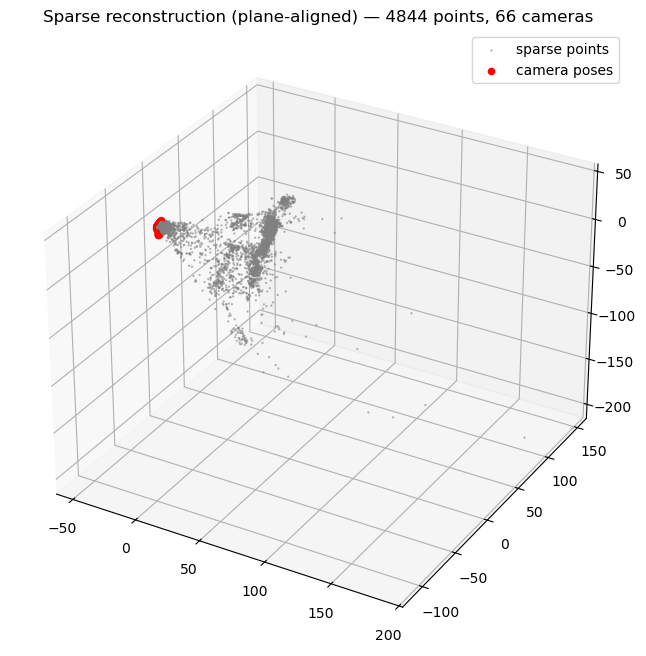

In [9]:
recon = pycolmap.Reconstruction(str(SPARSE_MODEL))
print(recon.summary())

def camera_center(image):
    if hasattr(image, "projection_center"):
        return image.projection_center()
    return image.cam_from_world.inverse().translation

points = np.array([p.xyz for p in recon.points3D.values()])
cams = np.array([camera_center(img) for img in recon.images.values()])

def plane_alignment_transform(pts):
    """4x4 transform that centers `pts` and rotates so their least-variance axis
    (the panel's surface normal) becomes Z. COLMAP's SfM output has an arbitrary
    orientation — this makes a flat/planar subject face the viewer head-on instead."""
    centroid = pts.mean(axis=0)
    cov = (pts - centroid).T @ (pts - centroid)
    eigvals, eigvecs = np.linalg.eigh(cov)  # ascending eigenvalues
    order = np.argsort(eigvals)
    R = np.stack([eigvecs[:, order[2]], eigvecs[:, order[1]], eigvecs[:, order[0]]])  # major, mid, normal -> X, Y, Z
    if np.linalg.det(R) < 0:
        R[2] *= -1
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = -R @ centroid
    return T

def apply_transform(T, pts):
    return (T[:3, :3] @ pts.T).T + T[:3, 3]

ALIGNMENT = plane_alignment_transform(points)
points_aligned = apply_transform(ALIGNMENT, points)
cams_aligned = apply_transform(ALIGNMENT, cams)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(points_aligned[:, 0], points_aligned[:, 1], points_aligned[:, 2], s=0.5, c="gray", alpha=0.5, label="sparse points")
ax.scatter(cams_aligned[:, 0], cams_aligned[:, 1], cams_aligned[:, 2], s=20, c="red", label="camera poses")
ax.set_title(f"Sparse reconstruction (plane-aligned) — {len(points)} points, {len(cams)} cameras")
ax.legend()
plt.show()

## 6. Filtered point cloud (skip meshing entirely)

The scatter plot above is the *raw* SfM output, which always includes noisy outlier points —
ones triangulated from very few images, or with high reprojection error. Filter those out using
`MIN_TRACK_LENGTH` / `MAX_REPROJ_ERROR` (config cell) before trusting the shape, then export
directly as a colored `.ply` point cloud — no mesh required.

In [ ]:
good_ids = [
    pid for pid, p in recon.points3D.items()
    if p.track.length() >= MIN_TRACK_LENGTH and p.error <= MAX_REPROJ_ERROR
]
print(f"Keeping {len(good_ids)}/{len(recon.points3D)} points after filtering "
      f"(MIN_TRACK_LENGTH={MIN_TRACK_LENGTH}, MAX_REPROJ_ERROR={MAX_REPROJ_ERROR})")

filtered_xyz = np.array([recon.points3D[pid].xyz for pid in good_ids])
filtered_rgb = np.array([recon.points3D[pid].color for pid in good_ids])  # uint8, 0-255
filtered_xyz_aligned = apply_transform(ALIGNMENT, filtered_xyz)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(filtered_xyz_aligned[:, 0], filtered_xyz_aligned[:, 1], filtered_xyz_aligned[:, 2],
           s=3, c=filtered_rgb / 255.0)
ax.set_title(f"Filtered point cloud (plane-aligned) — {len(good_ids)} points")
plt.show()

import trimesh

POINTCLOUD_PATH = WORKSPACE / "panel_pointcloud.ply"
trimesh.points.PointCloud(filtered_xyz_aligned, colors=filtered_rgb).export(str(POINTCLOUD_PATH))
print(f"Point cloud saved → {POINTCLOUD_PATH}")

## 6. Dense reconstruction (GPU only — skipped automatically without CUDA)

`patch_match_stereo` computes a dense depth map per image and requires an NVIDIA GPU. This cell checks for one and skips cleanly if none is found (expected on a Mac).

In [10]:
def has_cuda_gpu():
    if shutil.which("nvidia-smi") is None:
        return False
    return subprocess.run(["nvidia-smi"], capture_output=True).returncode == 0

USE_DENSE = has_cuda_gpu()
print(f"CUDA GPU detected: {USE_DENSE}")
if not USE_DENSE:
    print("No CUDA GPU — dense MVS needs one. Falling back to Delaunay meshing directly from the sparse point cloud (cell 7).")

CUDA GPU detected: False
No CUDA GPU — dense MVS needs one. Falling back to Delaunay meshing directly from the sparse point cloud (cell 7).


In [11]:
if USE_DENSE:
    run([
        "colmap", "image_undistorter",
        "--image_path", IMAGES_DIR,
        "--input_path", SPARSE_MODEL,
        "--output_path", DENSE_DIR,
        "--output_type", "COLMAP",
    ])
    run([
        "colmap", "patch_match_stereo",
        "--workspace_path", DENSE_DIR,
        "--workspace_format", "COLMAP",
        "--PatchMatchStereo.geom_consistency", "true",
    ])
    run([
        "colmap", "stereo_fusion",
        "--workspace_path", DENSE_DIR,
        "--workspace_format", "COLMAP",
        "--input_type", "geometric",
        "--output_path", DENSE_DIR / "fused.ply",
    ])
    print("Dense point cloud →", DENSE_DIR / "fused.ply")
else:
    print("Skipped (no CUDA GPU).")

Skipped (no CUDA GPU).


## 7. Mesh the building

- With dense points available: `poisson_mesher` gives a smooth, watertight surface.
- CPU-only fallback: `delaunay_mesher --input_type sparse` builds a mesh directly from the sparse SfM points — coarser, but needs no GPU.

In [12]:
MESH_PATH = WORKSPACE / "mesh.ply"

if USE_DENSE:
    run([
        "colmap", "poisson_mesher",
        "--input_path", DENSE_DIR / "fused.ply",
        "--output_path", MESH_PATH,
    ])
else:
    run([
        "colmap", "delaunay_mesher",
        "--input_path", SPARSE_MODEL,
        "--input_type", "sparse",
        "--output_path", MESH_PATH,
    ])
print(f"Mesh saved → {MESH_PATH}")

$ colmap delaunay_mesher --input_path colmap_ws/sparse/0 --input_type sparse --output_path colmap_ws/mesh.ply
Mesh saved → colmap_ws/mesh.ply


## 8. Visualize the mesh

In [13]:
import trimesh

mesh = trimesh.load(str(MESH_PATH))
mesh.apply_transform(ALIGNMENT)  # same plane-alignment computed above, so the mesh faces the viewer head-on
print(mesh)
mesh.show()  # interactive embedded viewer

<trimesh.Trimesh(vertices.shape=(1755, 3), faces.shape=(3484, 3))>


## 9. Export

`.obj`/`.glb` open in Blender, MeshLab, or any glTF viewer for further cleanup, texturing, or format conversion.

In [ ]:
EXPORT_OBJ = WORKSPACE / "building_model.obj"
EXPORT_GLB = WORKSPACE / "building_model.glb"

mesh.export(str(EXPORT_OBJ))
mesh.export(str(EXPORT_GLB))
print(f"Exported:\n  {EXPORT_OBJ}\n  {EXPORT_GLB}")

---
## Troubleshooting

| Symptom | Fix |
|---|---|
| `colmap`/`ffmpeg` not found | `brew install colmap ffmpeg` |
| Mapper reconstructs 0 models, or very few images registered | Increase `EXTRACT_FPS` for more overlap; check `BLUR_THRESHOLD` isn't dropping too many frames; orbit the building slowly rather than flying past it |
| Sparse reconstruction splits into several disconnected models | Fly a full loop around the building and enable `LOOP_CLOSURE` with a downloaded vocab tree |
| Mesh has holes / missing back or roof of the building | Capture more coverage — additional orbit passes at different heights/angles |
| `patch_match_stereo` fails or is skipped | Needs an NVIDIA GPU + CUDA — not available on Apple Silicon/Intel Macs. This notebook automatically falls back to sparse Delaunay meshing (cell 7) |
| Sparse Delaunay mesh looks coarse/blobby | Expected — it's built from sparse points only. For higher fidelity, rerun cells 6–7 on a CUDA machine (e.g. a cloud GPU instance) with the same `colmap_ws/` workspace |
| Feature matching very slow | Lower `EXTRACT_FPS`, or reduce frame resolution before extraction (`-vf fps=2,scale=1280:-1` in the ffmpeg command) |